# Prediction Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D  
  
from scripts.data_operation import transform_to_daily_stays
from scripts.constants import START_DATE, END_DATE, PREDICTION_HORIZON_DAYS

from scripts.data_preparation import (
    compute_base_prices,
    compute_relative_price_index,
    compute_occupancy_rate,
    build_historical_sample,
    prepare_full_occupancy_series,
)
from scripts.demand_forecasting import fit_sarima_model, forecast_occupancy
from scripts.distribution_estimation import estimate_joint_density, extract_conditional_distribution
from scripts.pricing import select_price_quantile, recommend_apartment_prices

## Section 2.2 — Data Aggregation and Preprocessing

In [2]:
relevant_data = pd.read_csv('data/relevant_data.csv', parse_dates=['start_date', 'end_date'])

listing_summary = relevant_data.groupby('apartment_id').agg(
    max_people_count=('beds_count', 'max'),
    num_reservations=('apartment_id', 'count'),
).reset_index()

total_capacity = listing_summary['max_people_count'].sum()

print(f"Apartments in segment : {len(listing_summary)}")
print(f"Total capacity (beds) : {total_capacity}")
listing_summary.head()

Apartments in segment : 13
Total capacity (beds) : 57


,apartment_id,max_people_count,num_reservations
0,0,3,142
1,1,4,128
2,2,8,127
3,3,5,99
4,4,4,119


In [3]:
# Expand booking records to one row per apartment per night
daily_stays = transform_to_daily_stays(relevant_data)
daily_stays['stay_date'] = pd.to_datetime(daily_stays['stay_date'])
daily_stays = daily_stays[
    (daily_stays['stay_date'] >= START_DATE) &
    (daily_stays['stay_date'] < END_DATE)
].reset_index(drop=True)

print(f"Records : {len(daily_stays)}")
print(f"Period  : {daily_stays['stay_date'].min().date()} -> {daily_stays['stay_date'].max().date()}")
daily_stays.head()

Records : 3787
Period  : 2024-04-28 -> 2025-05-26


,stay_date,apartment_id,price,beds_count,nightly_rate,nightly_bed_rate,apartment_bed_rate_pair
0,2024-05-13,0,757424,2,252475,126238,"(0, 126238)"
1,2024-05-14,0,757424,2,252475,126238,"(0, 126238)"
2,2024-05-15,0,757424,2,252475,126238,"(0, 126238)"
3,2024-05-15,5,975616,2,487808,243904,"(5, 243904)"
4,2024-05-16,5,975616,2,487808,243904,"(5, 243904)"


In [4]:
# Base price p_bar_a: historical average price per bed for each apartment
base_prices = compute_base_prices(daily_stays)

print("Base prices per bed (p_bar_a):")
base_prices.reset_index().rename(columns={'nightly_bed_rate': 'base_price_per_bed'})

Base prices per bed (p_bar_a):


,apartment_id,base_price_per_bed
0,0,196648.934985
1,1,205983.579710
2,2,153927.480892
3,3,136310.024221
4,4,146152.073099
5,5,161931.792332
6,6,162805.961661
7,7,192199.712025
8,8,272365.651429
9,9,168070.935976


In [5]:
# Relative price index r_t: beds-weighted average of (p_{a,t} / p_bar_a) across all apartments
relative_price_index = compute_relative_price_index(daily_stays, base_prices)

print(f"Days with r_t defined : {len(relative_price_index)}")
print(f"r_t range             : {relative_price_index.min():.3f} - {relative_price_index.max():.3f}")
print(f"r_t mean              : {relative_price_index.mean():.3f}  (should be approx 1.0)")

Days with r_t defined : 394
r_t range             : 0.435 - 1.889
r_t mean              : 0.911  (should be approx 1.0)


Historical sample size : 394 days
Occupancy range        : 0.053 - 0.702
Relative price range   : 0.435 - 1.889


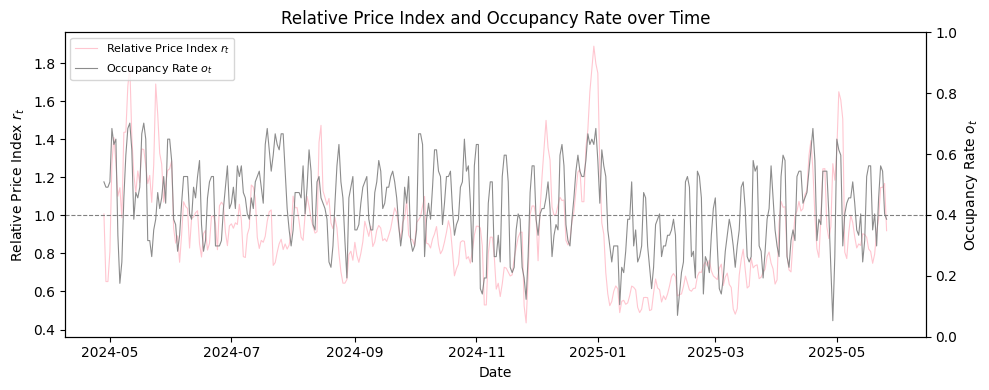

In [6]:
# Occupancy rate o_t on days with at least one booking
occupancy_rate_booked = compute_occupancy_rate(daily_stays, total_capacity)

# Historical sample D = {(o_t, r_t)}
historical_sample = build_historical_sample(occupancy_rate_booked, relative_price_index)

print(f"Historical sample size : {len(historical_sample)} days")
print(f"Occupancy range        : {historical_sample['occupancy_rate'].min():.3f} - {historical_sample['occupancy_rate'].max():.3f}")
print(f"Relative price range   : {historical_sample['relative_price_index'].min():.3f} - {historical_sample['relative_price_index'].max():.3f}")

fig, axes = plt.subplots(1, 1, figsize=(10, 4))

# Primary axis: relative price index (pink)
ln1 = axes.plot(relative_price_index.index, relative_price_index.values,
                color='pink', linewidth=0.8, alpha=0.9, label='Relative Price Index $r_t$')
axes.axhline(1.0, color='grey', linestyle='--', linewidth=0.8)
axes.set_title('Relative Price Index and Occupancy Rate over Time')
axes.set_xlabel('Date')
axes.set_ylabel('Relative Price Index $r_t$')
axes.tick_params(axis='y')

# Secondary axis: occupancy rate (gray)
ax0b = axes.twinx()
ln2 = ax0b.plot(occupancy_rate_booked.index, occupancy_rate_booked.values,
                color='gray', linewidth=0.8, alpha=0.9, label='Occupancy Rate $o_t$')
ax0b.set_ylabel('Occupancy Rate $o_t$')
ax0b.set_ylim(0, 1)
ax0b.tick_params(axis='y')

lines = ln1 + ln2
axes.legend(lines, [l.get_label() for l in lines], loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## Section 2.3 — Demand Forecasting with SARIMA

Training : 2024-04-28 -> 2025-04-26  (364 days)
Test     : 2025-04-27  -> 2025-05-26   (30 days)


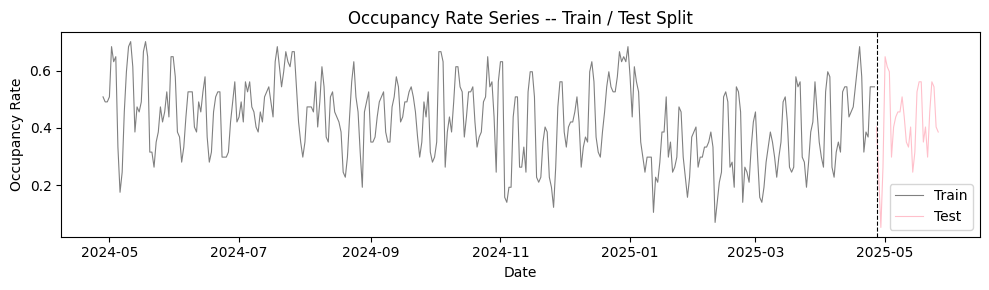

In [7]:
# Full occupancy series including zeros on unbooked days -- required for SARIMA
full_occupancy_series = prepare_full_occupancy_series(daily_stays, total_capacity, START_DATE, END_DATE)

train_occupancy = full_occupancy_series[:-PREDICTION_HORIZON_DAYS]
test_occupancy  = full_occupancy_series[-PREDICTION_HORIZON_DAYS:]

print(f"Training : {train_occupancy.index[0].date()} -> {train_occupancy.index[-1].date()}  ({len(train_occupancy)} days)")
print(f"Test     : {test_occupancy.index[0].date()}  -> {test_occupancy.index[-1].date()}   ({len(test_occupancy)} days)")

plt.figure(figsize=(10, 3))
plt.plot(train_occupancy.index, train_occupancy.values, label='Train', linewidth=0.8, color='gray')
plt.plot(test_occupancy.index,  test_occupancy.values,  label='Test',  linewidth=0.8, color='pink')
plt.axvline(test_occupancy.index[0], color='black', linestyle='--', linewidth=0.8)
plt.title('Occupancy Rate Series -- Train / Test Split')
plt.xlabel('Date')
plt.ylabel('Occupancy Rate')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# Fit SARIMA with weekly seasonality (m=7)
sarima_model = fit_sarima_model(train_occupancy, seasonal_period=7)
print(sarima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[7] intercept   : AIC=inf, Time=0.61 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=-556.781, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=-627.516, Time=0.15 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=-605.339, Time=0.17 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=-558.781, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=-556.430, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=-644.993, Time=0.29 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=-705.325, Time=0.55 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=0.34 sec
 ARIMA(1,1,0)(2,0,2)[7] intercept   : AIC=inf, Time=0.82 sec
 ARIMA(1,1,0)(1,0,2)[7] intercept   : AIC=inf, Time=0.65 sec
 ARIMA(0,1,0)(2,0,1)[7] intercept   : AIC=inf, Time=0.61 sec
 ARIMA(2,1,0)(2,0,1)[7] intercept   : AIC=-715.100, Time=0.73 sec
 ARIMA(2,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=0.41 sec
 ARIMA(2,1,0)(2,0,0)[7] intercept   : AIC=-646.753, Time=0.47 s

MAE  : 0.0729
RMSE : 0.0956


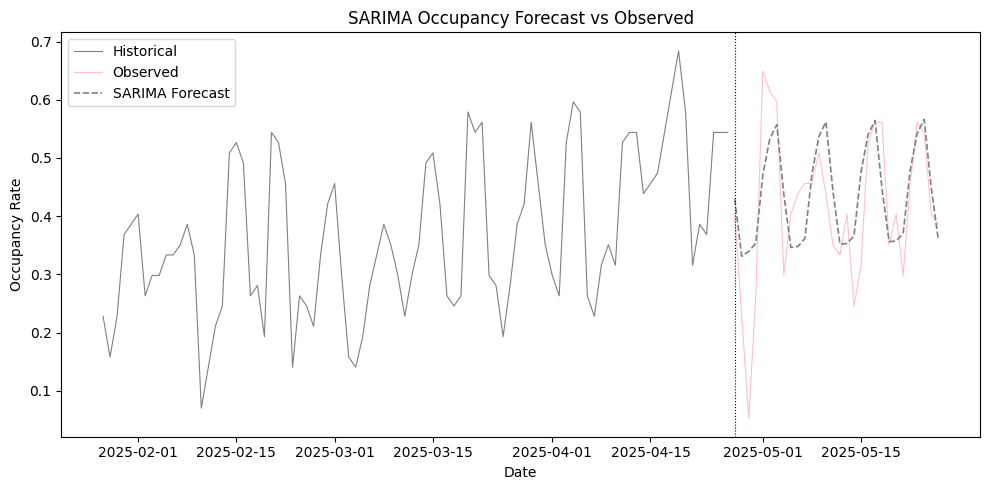

In [29]:
forecasted_occupancy = forecast_occupancy(sarima_model, horizon=PREDICTION_HORIZON_DAYS)
forecasted_dates = test_occupancy.index

mae  = np.mean(np.abs(test_occupancy.values - forecasted_occupancy))
rmse = np.sqrt(np.mean((test_occupancy.values - forecasted_occupancy) ** 2))
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(train_occupancy.index[-90:], train_occupancy.values[-90:], label='Historical', linewidth=0.8, color='gray')
plt.plot(forecasted_dates, test_occupancy.values,   label='Observed',          linewidth=0.8,   color='pink' )
plt.plot(forecasted_dates, forecasted_occupancy,    label='SARIMA Forecast', linewidth=1.2,linestyle='--', color='gray')
plt.axvline(forecasted_dates[0], color='black', linestyle=':', linewidth=0.8)
plt.title('SARIMA Occupancy Forecast vs Observed')
plt.xlabel('Date')
plt.ylabel('Occupancy Rate')
plt.legend( loc='upper left')
plt.tight_layout()
plt.show()

## Section 2.4 — Estimation of Historical Occupancy-Price Distribution

In [10]:
_, occupancy_grid, price_grid, density_grid = estimate_joint_density(historical_sample, grid_size=100)

print(f"KDE fitted on {len(historical_sample)} observations")
print(f"Grid: {len(occupancy_grid)} occupancy x {len(price_grid)} price points")

KDE fitted on 394 observations
Grid: 100 occupancy x 100 price points


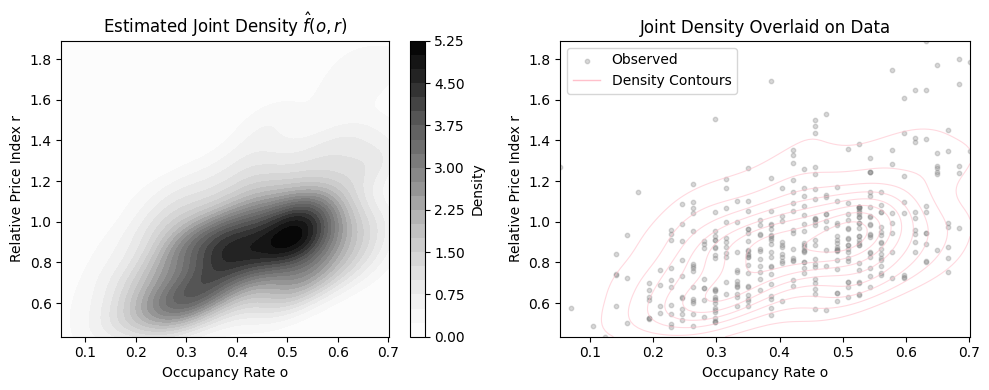

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cf = axes[0].contourf(occupancy_grid, price_grid, density_grid, levels=20, cmap='Greys')
fig.colorbar(cf, ax=axes[0], label='Density')
axes[0].set_title('Estimated Joint Density $\hat{f}(o, r)$')
axes[0].set_xlabel('Occupancy Rate o')
axes[0].set_ylabel('Relative Price Index r')

axes[1].scatter(
    historical_sample['occupancy_rate'],
    historical_sample['relative_price_index'],
    alpha=0.3,
    s=10,
    color='gray',
    label='Observed'
)

# Contour plot (no label here)
axes[1].contour(
    occupancy_grid,
    price_grid,
    density_grid,
    levels=8,
    colors='pink',
    linewidths=0.8,
    alpha=0.6
)

# Titles and labels
axes[1].set_title('Joint Density Overlaid on Data')
axes[1].set_xlabel('Occupancy Rate o')
axes[1].set_ylabel('Relative Price Index r')

# Create proxy artist for contour
contour_proxy = Line2D([0], [0], color='pink', lw=1)

# Get existing legend handles and labels, then append contour
handles, labels = axes[1].get_legend_handles_labels()
handles.append(contour_proxy)
labels.append('Density Contours')

# Final legend
axes[1].legend(handles, labels)

plt.tight_layout()
plt.show()

In [30]:
# Conditional distribution statistics at a reference occupancy level
o_ref = 0.4

cond_prices, cond_pdf = extract_conditional_distribution(
    occupancy_grid, price_grid, density_grid, o_ref
)

cond_mean = np.trapz(cond_prices * cond_pdf, cond_prices)
cond_var  = np.trapz((cond_prices - cond_mean) ** 2 * cond_pdf, cond_prices)
cond_std  = np.sqrt(cond_var)

price_range = (
    historical_sample["relative_price_index"].max()
    - historical_sample["relative_price_index"].min()
)
std_pct_of_range = cond_std / price_range * 100

print(f"Conditional distribution at o = {o_ref}:")
print(f"  E[R | O={o_ref}]     = {cond_mean:.4f}")
print(f"  std[R | O={o_ref}]   = {cond_std:.4f}")
print(f"  Total R range       = {price_range:.4f}")
print(f"  std as % of range   = {std_pct_of_range:.1f}%")


Conditional distribution at o = 0.4:
  E[R | O=0.4]     = 0.9026
  std[R | O=0.4]   = 0.2162
  Total R range       = 1.4545
  std as % of range   = 14.9%


Example: 2025-05-09  (t=12)
  Forecasted occupancy: o_hat_12 = 0.5373
  alpha=0.15  ->  r* = 0.7504
  alpha=0.50  ->  r* = 0.9541
  alpha=0.80  ->  r* = 1.1256


C:\Users\jrp\AppData\Local\Temp\ipykernel_22896\3431492249.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  o_hat_ex   = forecasted_occupancy[T_EXAMPLE]


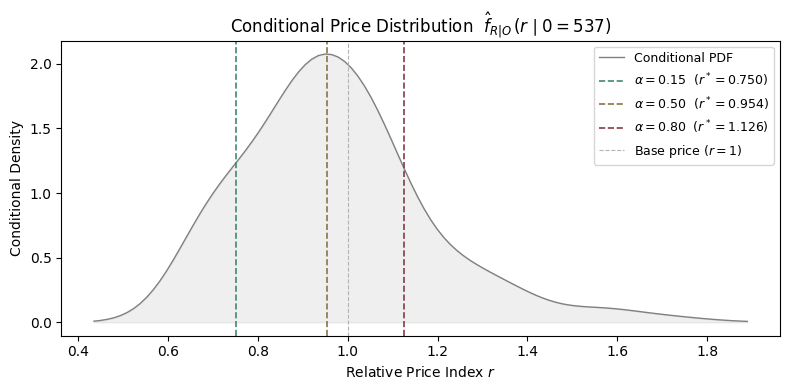

In [41]:
# Illustrative example: May 9 (t=12) conditional distribution and selected quantiles
T_EXAMPLE = 12
ALPHAS_EXAMPLE = [0.15, 0.5, 0.8]

o_hat_ex   = forecasted_occupancy[T_EXAMPLE]
date_ex    = forecasted_dates[T_EXAMPLE]

ex_prices, ex_cond_pdf = extract_conditional_distribution(
    occupancy_grid, price_grid, density_grid, o_hat_ex
)
quantiles_ex = {a: select_price_quantile(ex_prices, ex_cond_pdf, a) for a in ALPHAS_EXAMPLE}

print(f"Example: {date_ex.date()}  (t={T_EXAMPLE})")
print(f"  Forecasted occupancy: o_hat_{T_EXAMPLE} = {o_hat_ex:.4f}")
for a, q in quantiles_ex.items():
    print(f"  alpha={a:.2f}  ->  r* = {q:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(ex_prices, ex_cond_pdf, color="gray", linewidth=1, label="Conditional PDF")
ax.fill_between(ex_prices, ex_cond_pdf, alpha=0.12, color="gray")

q_colors = {0.15: "#418776", 0.5: "#897546", 0.8: "#853b47"}
q_styles = {0.15: "--", 0.5: "--", 0.8: "--"}
for a, q in quantiles_ex.items():
    ax.axvline(q, color=q_colors[a], linestyle=q_styles[a], linewidth=1.2,
               label=rf"$\alpha={a:.2f}$  ($r^* = {q:.3f}$)")


ax.axvline(1.0, color="#b4b4b4", linestyle="--", linewidth=0.8, label=r"Base price ($r=1$)")


date_str = date_ex.strftime("%Y-%m-%d")
title = (rf"Conditional Price Distribution  $\hat{{f}}_{{R|O}}\,(r\mid0 = 537)$")

ax.set_title(title)
ax.set_xlabel(r"Relative Price Index $r$")

ax.set_ylabel("Conditional Density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Section 2.5 — Pricing Decision

In [12]:
# alpha: pricing quantile -- 0 = most competitive, 1 = most aggressive
PRICING_QUANTILE = 0.5

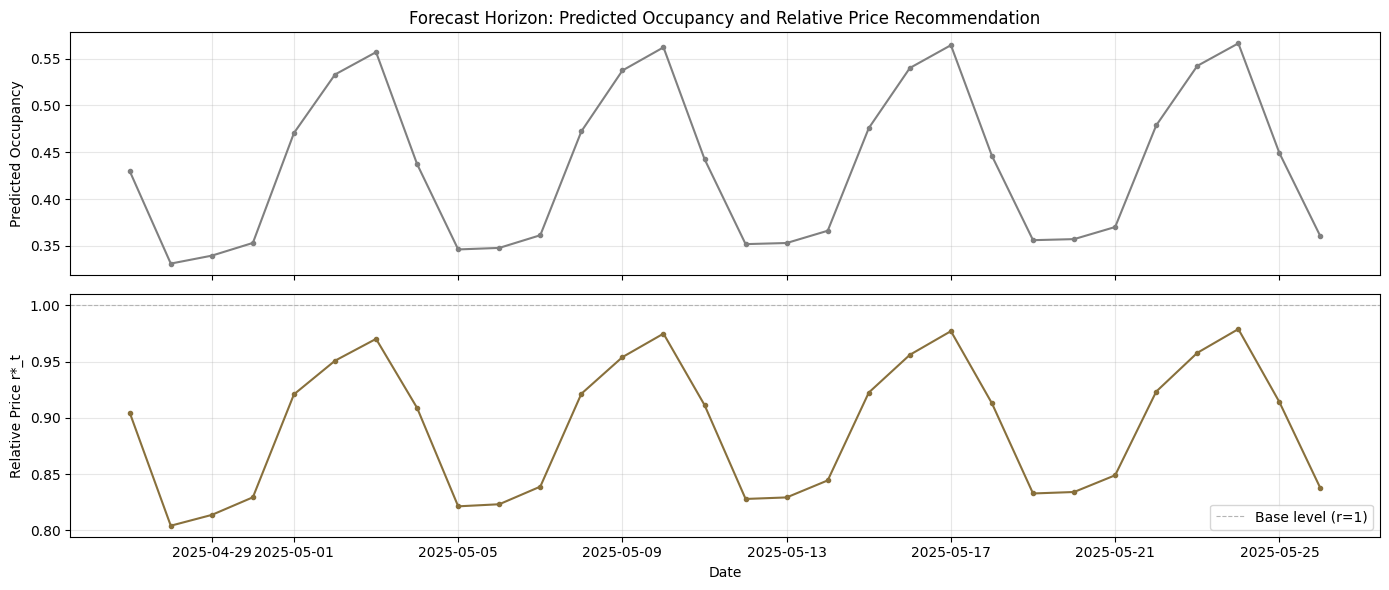

,predicted_occupancy,relative_price
date,,
2025-04-27,0.4299,0.9048
2025-04-28,0.3311,0.8043
2025-04-29,0.3396,0.8139
2025-04-30,0.3532,0.8295
2025-05-01,0.4705,0.9210
2025-05-02,0.5330,0.9509
2025-05-03,0.5569,0.9703
2025-05-04,0.4373,0.9089
2025-05-05,0.3462,0.8215


In [13]:
# Recommendations across the full forecast horizon
records = []

for date, predicted_occ in zip(forecasted_dates, forecasted_occupancy):
    try:
        p_axis, cond_pdf = extract_conditional_distribution(
            occupancy_grid, price_grid, density_grid, predicted_occ
        )
        rel_price  = select_price_quantile(p_axis, cond_pdf, PRICING_QUANTILE)
        apt_prices = recommend_apartment_prices(rel_price, base_prices)
        records.append({
            'date': date,
            'predicted_occupancy': predicted_occ,
            'relative_price': rel_price,
            **{f'apt_{aid}_price': price for aid, price in apt_prices.items()},
        })
    except ValueError as e:
        print(f"Skipping {date.date()}: {e}")

recommendations = pd.DataFrame(records).set_index('date')

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(recommendations.index, recommendations['predicted_occupancy'], marker='o', markersize=3, color='gray')
axes[0].set_ylabel('Predicted Occupancy')
axes[0].set_title('Forecast Horizon: Predicted Occupancy and Relative Price Recommendation')
axes[0].grid(True, alpha=0.3)

axes[1].plot(recommendations.index, recommendations['relative_price'], marker='o', markersize=3, color='#88703c')
axes[1].axhline(1.0, color='#B4B4B4', linestyle='--', linewidth=0.8, label='Base level (r=1)')
axes[1].set_ylabel('Relative Price r*_t')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

recommendations[['predicted_occupancy', 'relative_price']].round(4)

In [14]:
# Price recommendation table: nightly price per bed per apartment for the forecast horizon
apt_cols = [c for c in recommendations.columns if c.startswith('apt_') and c.endswith('_price')]
apt_ids  = [int(c.split('_')[1]) for c in apt_cols]

price_table = pd.DataFrame(index=recommendations.index)
price_table.index.name = 'date'
price_table['predicted_occupancy'] = recommendations['predicted_occupancy'].round(3)
price_table['relative_price_r*']   = recommendations['relative_price'].round(3)

for col, aid in zip(apt_cols, apt_ids):
    price_table[f'apt_{aid}'] = recommendations[col].round(0).astype(int)

print(f"Price recommendations (per bed): {len(price_table)} days  "
      f"({price_table.index[0].date()} → {price_table.index[-1].date()})")
price_table

Price recommendations (per bed): 30 days  (2025-04-27 → 2025-05-26)


,predicted_occupancy,relative_price_r*,apt_0,apt_1,apt_2,apt_3,apt_4,apt_5,apt_6,apt_7,apt_8,apt_9,apt_11,apt_12
date,,,,,,,,,,,,,,
2025-04-27,0.430,0.905,177924,186369,139270,123330,132235,146512,147303,173898,246430,152067,158084,129359
2025-04-28,0.331,0.804,158155,165663,123797,109628,117543,130234,130937,154577,219051,135171,140520,114987
2025-04-29,0.340,0.814,160045,167642,125276,110938,118948,131790,132502,156424,221668,136787,142199,116361
2025-04-30,0.353,0.830,163123,170866,127685,113071,121235,134324,135050,159432,225931,139417,144934,118598
2025-05-01,0.471,0.921,181116,189713,141769,125543,134608,149141,149946,177018,250852,154795,160921,131680
2025-05-02,0.533,0.951,186994,195870,146370,129618,138976,153981,154813,182763,258993,159819,166143,135954
2025-05-03,0.557,0.970,190809,199867,149357,132262,141812,157123,157971,186492,264278,163080,169533,138728
2025-05-04,0.437,0.909,178734,187218,139904,123892,132837,147179,147974,174690,247552,152759,158804,129948
2025-05-05,0.346,0.821,161542,169210,126447,111975,120060,133023,133741,157887,223741,138066,143529,117449


## Evaluation Metrics

### Demand Forecasting (SARIMA)

In [15]:
# ── SARIMA evaluation over the full test period ──────────────────────────────
occ_obs  = test_occupancy.values
occ_pred = forecasted_occupancy

mae_sarima  = np.mean(np.abs(occ_obs - occ_pred))
rmse_sarima = np.sqrt(np.mean((occ_obs - occ_pred) ** 2))
bias_sarima = np.mean(occ_pred - occ_obs)          # positive = model over-predicts

# Seasonal naive baseline: forecast for day h = observed value from same weekday
# in the last full week of training (h=0 → train[-7], h=7 → train[-7], etc.)
s = 7
naive_pred = np.array([train_occupancy.iloc[-s + (h % s)] for h in range(PREDICTION_HORIZON_DAYS)])
mae_naive  = np.mean(np.abs(occ_obs - naive_pred))

print("SARIMA forecast evaluation")
print(f"  Test period : {test_occupancy.index[0].date()} → {test_occupancy.index[-1].date()}  ({PREDICTION_HORIZON_DAYS} days)")
print(f"  MAE         : {mae_sarima:.4f}  ({mae_sarima*100:.2f} pp)")
print(f"  RMSE        : {rmse_sarima:.4f}  ({rmse_sarima*100:.2f} pp)")
print(f"  Mean bias   : {bias_sarima:+.4f}  ({bias_sarima*100:+.2f} pp)  [+= over-predicts, -= under-predicts]")
print()
print(f"  Naive seasonal baseline MAE : {mae_naive:.4f}  ({mae_naive*100:.2f} pp)")
print(f"  SARIMA improvement over naive : {(mae_naive - mae_sarima)*100:.2f} pp  ({(1 - mae_sarima/mae_naive)*100:.1f}% reduction)")

SARIMA forecast evaluation
  Test period : 2025-04-27 → 2025-05-26  (30 days)
  MAE         : 0.0729  (7.29 pp)
  RMSE        : 0.0956  (9.56 pp)
  Mean bias   : +0.0197  (+1.97 pp)  [+= over-predicts, -= under-predicts]

  Naive seasonal baseline MAE : 0.0936  (9.36 pp)
  SARIMA improvement over naive : 2.06 pp  (22.1% reduction)


In [16]:
# ── SARIMA smoothing diagnostics ──────────────────────────────────────────────
# Tests whether SARIMA compresses the spread of occupancy rather than
# producing a single-direction bias (errors of opposite sign cancel in mean bias).

errors = occ_pred - occ_obs    # positive = model over-predicts

# 1. Spread comparison: does the model produce lower variance than reality?
print("Spread comparison:")
print(f"  Std dev of observed occupancy  : {occ_obs.std()*100:.2f} pp")
print(f"  Std dev of predicted occupancy : {occ_pred.std()*100:.2f} pp")
print(f"  Ratio pred/obs std             : {occ_pred.std()/occ_obs.std():.3f}  (<1.0 confirms compression)")

# 2. Signed error split by demand level
# If smoothing: model over-predicts on quiet days (error > 0) and under-predicts on busy days (error < 0)
median_occ = np.median(occ_obs)
low_mask  = occ_obs <  median_occ
high_mask = occ_obs >= median_occ

print(f"\nSigned error (pred − obs) split at median actual occupancy ({median_occ*100:.1f}%):")
print(f"  Low demand  days (n={low_mask.sum():2d}, obs < median) : mean error = {errors[low_mask].mean()*100:+.2f} pp")
print(f"  High demand days (n={high_mask.sum():2d}, obs ≥ median) : mean error = {errors[high_mask].mean()*100:+.2f} pp")
print(f"  (smoothing pattern = positive on low-demand, negative on high-demand)")

# 3. Correlation between actual occupancy level and forecast error
corr = np.corrcoef(occ_obs, errors)[0, 1]
print(f"\nCorrelation (actual occupancy, forecast error) : {corr:.3f}")
print(f"  (negative = smoothing dominates: higher actual demand → model under-predicts more)")

Spread comparison:
  Std dev of observed occupancy  : 13.00 pp
  Std dev of predicted occupancy : 8.35 pp
  Ratio pred/obs std             : 0.642  (<1.0 confirms compression)

Signed error (pred − obs) split at median actual occupancy (40.4%):
  Low demand  days (n=11, obs < median) : mean error = +9.65 pp
  High demand days (n=19, obs ≥ median) : mean error = -2.48 pp
  (smoothing pattern = positive on low-demand, negative on high-demand)

Correlation (actual occupancy, forecast error) : -0.778
  (negative = smoothing dominates: higher actual demand → model under-predicts more)


### Pricing Recommendations

In [17]:
# ── Observed prices per apartment per day in the test period ─────────────────
# Weighted average nightly_bed_rate (weight = beds_count) to match how base prices
# are defined, so the relative errors are on a consistent scale.
test_daily = daily_stays[daily_stays['stay_date'].isin(forecasted_dates)].copy()

test_daily['weighted_price'] = test_daily['nightly_bed_rate'] * test_daily['beds_count']

obs_prices = (
    test_daily
    .groupby(['stay_date', 'apartment_id'])
    .agg(weighted_price_sum=('weighted_price', 'sum'), beds_sum=('beds_count', 'sum'))
    .reset_index()
)
obs_prices['obs_price_per_bed'] = obs_prices['weighted_price_sum'] / obs_prices['beds_sum']
obs_prices = obs_prices.drop(columns=['weighted_price_sum', 'beds_sum'])
obs_prices['stay_date'] = pd.to_datetime(obs_prices['stay_date'])

# ── Recommended prices in long format ────────────────────────────────────────
apt_cols = [c for c in recommendations.columns if c.startswith('apt_') and c.endswith('_price')]
rec_long = (
    recommendations[apt_cols]
    .reset_index()
    .melt(id_vars='date', var_name='apt_col', value_name='rec_price_per_bed')
)
rec_long['apartment_id'] = rec_long['apt_col'].str.extract(r'apt_(\d+)_price').astype(int)
rec_long = rec_long.drop(columns='apt_col')

# ── Merge on date × apartment ─────────────────────────────────────────────────
eval_df = rec_long.merge(
    obs_prices,
    left_on=['date', 'apartment_id'],
    right_on=['stay_date', 'apartment_id'],
    how='inner',
).drop(columns='stay_date')

# Relative price error: (recommended - observed) / observed
eval_df['rel_error'] = (eval_df['rec_price_per_bed'] - eval_df['obs_price_per_bed']) / eval_df['obs_price_per_bed']

# Relative price of each apartment on each day (observed vs its own base price)
eval_df['obs_relative'] = eval_df['apartment_id'].map(base_prices)
eval_df['obs_relative'] = eval_df['obs_price_per_bed'] / eval_df['obs_relative']
eval_df['rec_relative'] = eval_df['rec_price_per_bed'] / eval_df['apartment_id'].map(base_prices)

print(f"Evaluation pairs: {len(eval_df)}  "
      f"({eval_df['apartment_id'].nunique()} apartments × test dates with at least one booking)")

Evaluation pairs: 290  (12 apartments × test dates with at least one booking)


In [18]:
# ── Aggregate pricing evaluation metrics ─────────────────────────────────────
mean_bias   = eval_df['rel_error'].mean()          # signed: negative = under-pricing
mae_price   = eval_df['rel_error'].abs().mean()
std_price   = eval_df['rel_error'].std()

# Directional accuracy: does the model correctly predict whether to price
# above or below each apartment's historical average (base price)?
# A tie (either side exactly at 1.0) is excluded as ambiguous.
dir_df = eval_df[(eval_df['obs_relative'] != 1.0) & (eval_df['rec_relative'] != 1.0)].copy()
dir_df['direction_correct'] = np.sign(dir_df['rec_relative'] - 1.0) == np.sign(dir_df['obs_relative'] - 1.0)
directional_accuracy = dir_df['direction_correct'].mean()

print("Pricing recommendation evaluation  (α = {:.1f}, full test period, all apartments)".format(PRICING_QUANTILE))
print(f"  Evaluation pairs         : {len(eval_df)}")
print(f"  Mean signed error (bias) : {mean_bias*100:+.1f}%  [negative = model under-prices]")
print(f"  Mean absolute error      : {mae_price*100:.1f}%")
print(f"  Std dev of error         : {std_price*100:.1f}%")
print(f"  Directional accuracy     : {directional_accuracy*100:.1f}%  ({dir_df['direction_correct'].sum()}/{len(dir_df)} pairs)")

Pricing recommendation evaluation  (α = 0.5, full test period, all apartments)
  Evaluation pairs         : 290
  Mean signed error (bias) : -4.2%  [negative = model under-prices]
  Mean absolute error      : 28.4%
  Std dev of error         : 34.7%
  Directional accuracy     : 51.7%  (150/290 pairs)


In [19]:
# ── Per-apartment breakdown ───────────────────────────────────────────────────
apt_summary = (
    eval_df
    .groupby('apartment_id')['rel_error']
    .agg(
        n='count',
        mean_bias=lambda x: x.mean(),
        mae=lambda x: x.abs().mean(),
        std='std',
    )
    .reset_index()
)
apt_summary[['mean_bias', 'mae', 'std']] *= 100   # convert to %

dir_per_apt = (
    dir_df.groupby('apartment_id')['direction_correct']
    .mean()
    .mul(100)
    .rename('dir_acc_%')
    .reset_index()
)
apt_summary = apt_summary.merge(dir_per_apt, on='apartment_id', how='left')

apt_summary = apt_summary.rename(columns={
    'n':         'pairs',
    'mean_bias': 'mean_bias_%',
    'mae':       'mae_%',
    'std':       'std_%',
})

print("Per-apartment pricing evaluation:")
print(apt_summary.round(1).to_string(index=False))

Per-apartment pricing evaluation:
 apartment_id  pairs  mean_bias_%  mae_%  std_%  dir_acc_%
            0     25        -19.8   39.6   41.8       32.0
            1     26         -3.2   22.6   25.7       34.6
            2     26         16.1   34.6   39.9       88.5
            3     25         -6.5   21.6   24.5       56.0
            4     23        -29.2   32.0   24.7       26.1
            5     23          0.7   14.8   21.1       73.9
            6     20          8.6   32.1   43.1       65.0
            7     24        -11.2   37.2   41.8       16.7
            8     29          3.9   20.6   25.8       75.9
            9     26         -9.7   32.8   34.7       46.2
           11     19         -7.4   16.4   19.3       52.6
           12     24          6.0   36.0   41.5       50.0


In [20]:
# ── Pricing errors split by actual demand level ───────────────────────────────
# Tests whether the occupancy smoothing pattern propagates into pricing:
#   low-demand days  → SARIMA over-predicts occ → model should over-price  (error > 0)
#   high-demand days → SARIMA under-predicts occ → model should under-price (error < 0)

# Attach the per-day actual occupancy and demand label to each apartment-level pricing pair
occ_df = pd.DataFrame({
    'date':          forecasted_dates,
    'obs_occupancy': occ_obs,
}).assign(demand_group=lambda df: np.where(
    df['obs_occupancy'] < np.median(occ_obs), 'low', 'high'
))

eval_split = eval_df.merge(occ_df, on='date', how='left')

for group in ['low', 'high']:
    sub = eval_split[eval_split['demand_group'] == group]
    n_days = sub['date'].nunique()
    print(f"{group.capitalize()}-demand days  "
          f"(n={n_days} days, {len(sub)} apartment-day pairs, "
          f"obs occ < {np.median(occ_obs)*100:.1f}%" if group == 'low' else
          f"obs occ ≥ {np.median(occ_obs)*100:.1f}%)")
    print(f"  Mean signed error : {sub['rel_error'].mean()*100:+.1f}%")
    print(f"  MAE               : {sub['rel_error'].abs().mean()*100:.1f}%")
    print(f"  Std dev           : {sub['rel_error'].std()*100:.1f}%")
    print()

Low-demand days  (n=11 days, 83 apartment-day pairs, obs occ < 40.4%
  Mean signed error : -3.8%
  MAE               : 29.1%
  Std dev           : 35.6%

obs occ ≥ 40.4%)
  Mean signed error : -4.3%
  MAE               : 28.2%
  Std dev           : 34.4%



### Occupancy–Price Trend Analysis

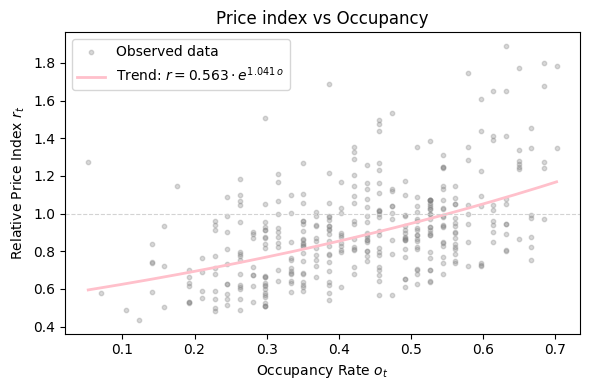

Exponential fit  (selected):  r = 0.5630 * exp(1.0405 * o)
  Intercept (o=0)           : r = 0.563
  Effect of +10 pp occupancy: price factor × 1.110


In [21]:
# ── Exponential trend: selected dataset (analysis window, 13-apartment segment) ──
# Fits r = a * exp(b * o) via linearisation: log(r) = log(a) + b*o
x = historical_sample['occupancy_rate'].values
y = historical_sample['relative_price_index'].values

# Only use strictly positive r values (log is undefined at 0)
mask = y > 0
b_sel, log_a_sel = np.polyfit(x[mask], np.log(y[mask]), 1)
a_sel = np.exp(log_a_sel)

x_line = np.linspace(x.min(), x.max(), 300)
y_line = a_sel * np.exp(b_sel * x_line)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, alpha=0.3, s=10, color='gray', label=f'Observed data')
ax.plot(x_line, y_line, color='pink', linewidth=2,
        label=f'Trend: $r = {a_sel:.3f}\\cdot e^{{{b_sel:.3f}\\,o}}$')
ax.axhline(1.0, color='lightgray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Occupancy Rate $o_t$')
ax.set_ylabel('Relative Price Index $r_t$')
ax.set_title('Price index vs Occupancy')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Exponential fit  (selected):  r = {a_sel:.4f} * exp({b_sel:.4f} * o)")
print(f"  Intercept (o=0)           : r = {a_sel:.3f}")
print(f"  Effect of +10 pp occupancy: price factor × {np.exp(b_sel * 0.1):.3f}")

Full dataset : 588 days  (2023-10-27 → 2025-06-05)


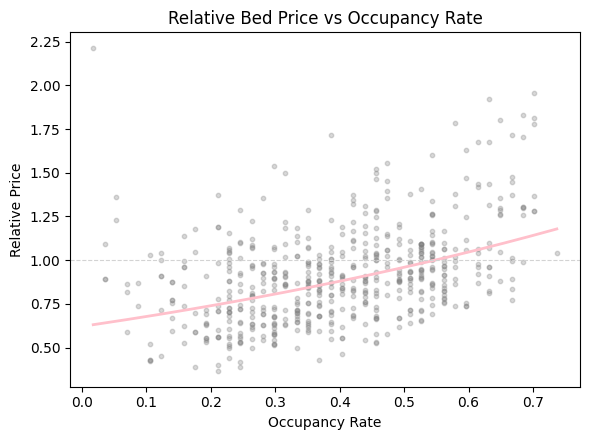


Exponential fit (full)    :  r = 0.6211 * exp(0.8693 * o)
Exponential fit (selected):  r = 0.5630 * exp(1.0405 * o)


In [22]:
# ── Exponential trend: full dataset (all reservations, no date filter) ───────
full_daily = transform_to_daily_stays(relevant_data)
full_daily['stay_date'] = pd.to_datetime(full_daily['stay_date'])

full_base_prices  = compute_base_prices(full_daily)
full_capacity     = listing_summary['max_people_count'].sum()
full_occ          = compute_occupancy_rate(full_daily, full_capacity)
full_rpi          = compute_relative_price_index(full_daily, full_base_prices)
full_sample       = build_historical_sample(full_occ, full_rpi)

print(f"Full dataset : {len(full_sample)} days  "
      f"({full_sample.index.min().date()} → {full_sample.index.max().date()})")

x_f = full_sample['occupancy_rate'].values
y_f = full_sample['relative_price_index'].values

mask_f = y_f > 0
b_full, log_a_full = np.polyfit(x_f[mask_f], np.log(y_f[mask_f]), 1)
a_full = np.exp(log_a_full)

x_line_f = np.linspace(x_f.min(), x_f.max(), 300)
y_line_f  = a_full * np.exp(b_full * x_line_f)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.scatter(x_f, y_f, alpha=0.3, s=10, color='gray', )
ax.plot(x_line_f, y_line_f, color='pink', linewidth=2,
        label=f'Exp. trend: $r = {a_full:.3f}\\cdot e^{{{b_full:.3f}\\,o}}$')
ax.axhline(1.0, color='lightgray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Occupancy Rate')
ax.set_ylabel('Relative Price')
ax.set_title('Relative Bed Price vs Occupancy Rate')
# ax.legend()
plt.tight_layout()
plt.show()

print(f"\nExponential fit (full)    :  r = {a_full:.4f} * exp({b_full:.4f} * o)")
print(f"Exponential fit (selected):  r = {a_sel:.4f} * exp({b_sel:.4f} * o)")

### Run Metrics Export

In [23]:
import json

# ── Collect all metrics for this run into a single dict ───────────────────────
# Pricing split metrics (recompute from eval_split to avoid scope issues)
low_sub  = eval_split[eval_split['demand_group'] == 'low']['rel_error']
high_sub = eval_split[eval_split['demand_group'] == 'high']['rel_error']

run_metrics = {
    # -- run configuration --
    "config": {
        "start_date":            str(train_occupancy.index[0].date()),
        "train_end_date":        str(train_occupancy.index[-1].date()),
        "test_start_date":       str(test_occupancy.index[0].date()),
        "test_end_date":         str(test_occupancy.index[-1].date()),
        "n_training_days":       int(len(train_occupancy)),
        "n_test_days":           int(PREDICTION_HORIZON_DAYS),
        "n_apartments":          int(eval_df['apartment_id'].nunique()),
        "total_capacity_beds":   int(total_capacity),
        "pricing_quantile_alpha": float(PRICING_QUANTILE)
    },
    # -- SARIMA forecasting --
    "sarima": {
        "mae_pp":                round(float(mae_sarima * 100), 4),
        "rmse_pp":               round(float(rmse_sarima * 100), 4),
        "mean_bias_pp":          round(float(bias_sarima * 100), 4),
        "std_observed_pp":       round(float(occ_obs.std() * 100), 4),
        "std_predicted_pp":      round(float(occ_pred.std() * 100), 4),
        "std_compression_ratio": round(float(occ_pred.std() / occ_obs.std()), 4),
        "corr_occ_vs_error":     round(float(corr), 4),
        "naive_baseline_mae_pp": round(float(mae_naive * 100), 4),
        "improvement_over_naive_pp":   round(float((mae_naive - mae_sarima) * 100), 4),
        "improvement_over_naive_pct":  round(float((1 - mae_sarima / mae_naive) * 100), 2),
        "low_demand_bias_pp":    round(float(errors[low_mask].mean() * 100), 4),
        "high_demand_bias_pp":   round(float(errors[high_mask].mean() * 100), 4),
    },
    # -- pricing recommendations --
    "pricing": {
        "n_evaluation_pairs":    int(len(eval_df)),
        "mean_bias_pct":         round(float(mean_bias * 100), 2),
        "mae_pct":               round(float(mae_price * 100), 2),
        "std_pct":               round(float(std_price * 100), 2),
        "directional_accuracy":  round(float(directional_accuracy * 100), 2),
        "low_demand_mean_bias_pct":  round(float(low_sub.mean() * 100), 2),
        "high_demand_mean_bias_pct": round(float(high_sub.mean() * 100), 2),
    },
    # -- occupancy–price exponential trend --
    "exp_trend": {
        "selected_a": round(float(a_sel), 6),
        "selected_b": round(float(b_sel), 6),
        "full_a":     round(float(a_full), 6),
        "full_b":     round(float(b_full), 6),
    },
}

# ── Print summary ─────────────────────────────────────────────────────────────
print(json.dumps(run_metrics, indent=2))

# ── Save to file ──────────────────────────────────────────────────────────────
label = f"{run_metrics['config']['start_date']}_to_{run_metrics['config']['test_end_date']}_alpha{PRICING_QUANTILE}"
out_path = f"metrics_{label}.json"
with open(out_path, "w") as f:
    json.dump(run_metrics, f, indent=2)
print(f"\nSaved → {out_path}")

{
  "config": {
    "start_date": "2024-04-28",
    "train_end_date": "2025-04-26",
    "test_start_date": "2025-04-27",
    "test_end_date": "2025-05-26",
    "n_training_days": 364,
    "n_test_days": 30,
    "n_apartments": 12,
    "total_capacity_beds": 57,
    "pricing_quantile_alpha": 0.5
  },
  "sarima": {
    "mae_pp": 7.2931,
    "rmse_pp": 9.563,
    "mean_bias_pp": 1.9651,
    "std_observed_pp": 13.0005,
    "std_predicted_pp": 8.3457,
    "std_compression_ratio": 0.642,
    "corr_occ_vs_error": -0.7778,
    "naive_baseline_mae_pp": 9.3567,
    "improvement_over_naive_pp": 2.0636,
    "improvement_over_naive_pct": 22.05,
    "low_demand_bias_pp": 9.6476,
    "high_demand_bias_pp": -2.4826
  },
  "pricing": {
    "n_evaluation_pairs": 290,
    "mean_bias_pct": -4.17,
    "mae_pct": 28.44,
    "std_pct": 34.7,
    "directional_accuracy": 51.72,
    "low_demand_mean_bias_pct": -3.81,
    "high_demand_mean_bias_pct": -4.31
  },
  "exp_trend": {
    "selected_a": 0.563004,
    "s